# Exploracion de Steam_data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Cargamos los datos

In [2]:
df_raw = pd.read_csv("steam_data.csv", sep=";", encoding="utf-8-sig")
df_raw.shape

(62267, 4)

### Limpieza

In [3]:
df = df_raw.copy()
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
df["Players"] = pd.to_numeric(df["Players"], errors="coerce")
# Average Players se conserva tal cual (sin rellenar ni eliminar).
df["Fecha"] = df["DateTime"].dt.floor("D")
df["Año"] = df["DateTime"].dt.year
df["Mes"] = df["DateTime"].dt.month
df["Dia"] = df["DateTime"].dt.day
df["Hora"] = df["DateTime"].dt.hour
df_limpio = df.dropna(subset=["Game", "DateTime", "Players"]).copy()
diario_juego = (
    df_limpio.groupby(["Game", "Fecha"])["Players"]
    .mean()
    .reset_index()
    .sort_values(["Game", "Fecha"])
    .reset_index(drop=True)
)
print("filas:", len(df), "| juegos:", df["Game"].nunique())
print("rango:", df["Fecha"].min(), "->", df["Fecha"].max())
print("diario_juego:", diario_juego.shape)

filas: 62267 | juegos: 10
rango: 2007-09-19 00:00:00 -> 2026-10-05 00:00:00
diario_juego: (45269, 3)


### Utilidades compartidas (graficos, tablas y resumenes)

In [4]:
def barras(x, y, titulo, xlabel, ylabel, horizontal=False, color=None,
           figsize=(11, 5), rotacion=45, linea_cero=False):
    """Barras verticales u horizontales con el estilo comun."""
    plt.figure(figsize=figsize)
    if horizontal:
        plt.barh(x, y, color=color)
        plt.gca().invert_yaxis()
    else:
        plt.bar(x, y, color=color)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if not horizontal:
        plt.xticks(rotation=rotacion)
    if linea_cero:
        plt.axvline(0, color="black", linewidth=1)
    plt.grid(axis="x" if horizontal else "y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def configurar(ax, titulo, xlabel, ylabel, eje_grid=True, rotacion_x=None):
    """Titulos, etiquetas y rejilla comunes para ejes line/scatter."""
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(eje_grid, linestyle="--", alpha=0.5)
    if rotacion_x is not None:
        ax.tick_params(axis="x", rotation=rotacion_x)


def tabla(datos, formato):
    """Muestra una tabla con formato numerico/fecha consistente."""
    if formato is None:
        display(datos)
    else:
        display(datos.style.format(formato))


def formato_porcentaje(valor):
    return f"{valor:.2f}".rstrip("0").rstrip(".") + " %"


def max_min(serie):
    """Devuelve (idxmax, idxmin) de una serie de promedios."""
    return serie.idxmax(), serie.idxmin()


def promedio_hora(marco, inicio=None, fin=None):
    """Promedio de Players por hora, opcionalmente en una ventana [inicio, fin]."""
    vista = marco
    if inicio is not None:
        vista = vista[vista["DateTime"] >= inicio]
    if fin is not None:
        vista = vista[vista["DateTime"] <= fin]
    return vista.groupby("Hora")["Players"].mean().reindex(range(24)).dropna()


def calcular_retencion(promedios):
    """Retencion por juego: ultimo promedio diario frente a su pico.

    Devuelve (comparacion ordenada, historiales por juego).
    """
    resultados = []
    historiales = {}
    for juego, historial in promedios.groupby("Game"):
        historial = historial.copy()
        fila_pico = historial.loc[historial["Players"].idxmax()]
        ultimo_registro = historial.iloc[-1]
        pico = fila_pico["Players"]
        porcentaje_conservado = (
            round(ultimo_registro["Players"] / pico * 100, 2) if pico > 0 else 0
        )
        historiales[juego] = (historial, pico)
        resultados.append(
            {
                "Juego": juego,
                "Fecha del pico": fila_pico["Fecha"],
                "Pico de jugadores": pico,
                "Última fecha": ultimo_registro["Fecha"],
                "Promedio actual de jugadores": ultimo_registro["Players"],
                "% conservado del pico": porcentaje_conservado,
                "% perdido": 100 - porcentaje_conservado,
            }
        )
    comparacion = (
        pd.DataFrame(resultados)
        .sort_values("% conservado del pico", ascending=False)
        .reset_index(drop=True)
    )
    return comparacion, historiales

## 2. Forma y estructura

In [5]:
print(df_raw.shape)
print(df_raw.columns.tolist())
print(df_raw.dtypes)
df_raw.info()

(62267, 4)
['Game', 'DateTime', 'Players', 'Average Players']
Game                   str
DateTime               str
Players            float64
Average Players    float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 62267 entries, 0 to 62266
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Game             62267 non-null  str    
 1   DateTime         62267 non-null  str    
 2   Players          60652 non-null  float64
 3   Average Players  14815 non-null  float64
dtypes: float64(2), str(2)
memory usage: 1.9 MB


## 3. Valores null y descripcion

In [6]:
print(df_raw.isna().sum())
print('Average Players con dato: '
      f'{df_raw["Average Players"].notna().mean():.1%}')
# Average Players se conserva tal cual: columna mayoritariamente vacia,
# sin rellenar ni eliminar; las preguntas actuales usan Players.
df_raw.describe(include="all")

Game                   0
DateTime               0
Players             1615
Average Players    47452
dtype: int64
Average Players con dato: 23.8%


,Game,DateTime,Players,Average Players
count,62267,62267,6.065200e+04,1.481500e+04
unique,10,8500,NaN,NaN
top,Team Fortress 2,2018-11-16 00:00:00,NaN,NaN
freq,8495,10,NaN,NaN
mean,NaN,NaN,2.365319e+05,1.923764e+05
std,NaN,NaN,3.667164e+05,2.790480e+05
min,NaN,NaN,1.000000e+00,2.615000e+03
25%,NaN,NaN,1.733350e+04,2.274000e+04
50%,NaN,NaN,5.428950e+04,5.750200e+04
75%,NaN,NaN,3.876900e+05,2.765325e+05


## 4. Vistazo a los datos

In [7]:
display(df_raw.head())
display(df_raw.tail())

,Game,DateTime,Players,Average Players
0,Among Us,2018-11-16 00:00:00,8.0,NaN
1,Among Us,2018-11-17 00:00:00,17.0,NaN
2,Among Us,2018-11-18 00:00:00,11.0,NaN
3,Among Us,2018-11-19 00:00:00,7.0,NaN
4,Among Us,2018-11-20 00:00:00,8.0,NaN


,Game,DateTime,Players,Average Players
62262,Terraria,2026-10-05 06:30:00,30841.0,NaN
62263,Terraria,2026-10-05 06:40:00,31138.0,NaN
62264,Terraria,2026-10-05 06:50:00,31317.0,NaN
62265,Terraria,2026-10-05 07:00:00,31385.0,38652.0
62266,Terraria,2026-10-05 07:10:00,31542.0,38652.0


In [8]:
print("n_games:", df_raw["Game"].nunique())
print(sorted(df_raw["Game"].unique()))
print("date min:", df["Fecha"].min())
print("date max:", df["Fecha"].max())

n_games: 10
['Among Us', 'Counter-Strike 2', 'Dota 2', 'Hollow Knight', 'PUBG', 'Project Zomboid', 'Rust', 'Stardew Valley', 'Team Fortress 2', 'Terraria']
date min: 2007-09-19 00:00:00
date max: 2026-10-05 00:00:00


## 5. Analisis

### ¿Cuales son los meses con mayor y menor cantidad de jugadores?

Mayor promedio: Marzo (263,412 jugadores)
Menor promedio: Septiembre (212,666 jugadores)


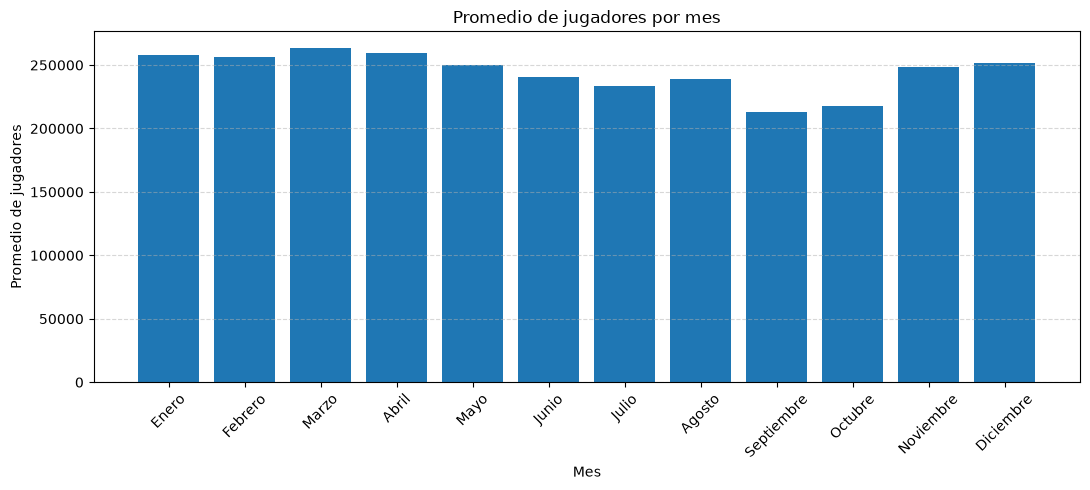

In [9]:
nombres_meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

mes_promedio = df.groupby("Mes")["Players"].mean().reindex(range(1, 13))
mes_promedio = mes_promedio.dropna()

mes_maximo, mes_minimo = max_min(mes_promedio)

print(
    f"Mayor promedio: {nombres_meses[mes_maximo - 1]} "
    f"({mes_promedio.loc[mes_maximo]:,.0f} jugadores)"
)
print(
    f"Menor promedio: {nombres_meses[mes_minimo - 1]} "
    f"({mes_promedio.loc[mes_minimo]:,.0f} jugadores)"
)

barras(
    [nombres_meses[mes - 1] for mes in mes_promedio.index],
    mes_promedio.values,
    titulo="Promedio de jugadores por mes",
    xlabel="Mes",
    ylabel="Promedio de jugadores",
)

### ¿Cual es la hora con mayor y menor cantidad de jugadores?

Mayor promedio: a las 14:00 (310,887 jugadores)
Menor promedio: a las 01:00 (127,761 jugadores)


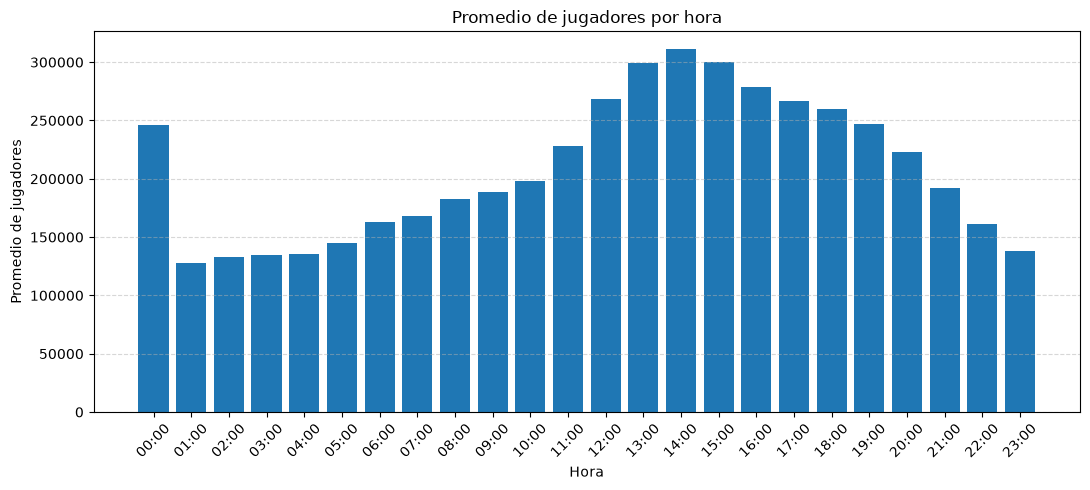

In [10]:
hora_promedio = promedio_hora(df)

hora_maxima, hora_minima = max_min(hora_promedio)

print(
    f"Mayor promedio: a las {hora_maxima:02d}:00 "
    f"({hora_promedio.loc[hora_maxima]:,.0f} jugadores)"
)
print(
    f"Menor promedio: a las {hora_minima:02d}:00 "
    f"({hora_promedio.loc[hora_minima]:,.0f} jugadores)"
)

barras(
    [f"{hora:02d}:00" for hora in hora_promedio.index],
    hora_promedio.values,
    titulo="Promedio de jugadores por hora",
    xlabel="Hora",
    ylabel="Promedio de jugadores",
)

- Hay que recalcar que el pico a las 00:00 se debe a que los datos mas antiguos de un mes no estan dividos por hora y solo tienen una entrada para todo el dia, el cual se coloca a las 00:00. Si no tuvieramos en cuenta los datos anteriores al 05/09 el resultado seria el siguiente:

Mayor promedio: a las 14:00 (310,887 jugadores)
Menor promedio: a las 01:00 (127,761 jugadores)


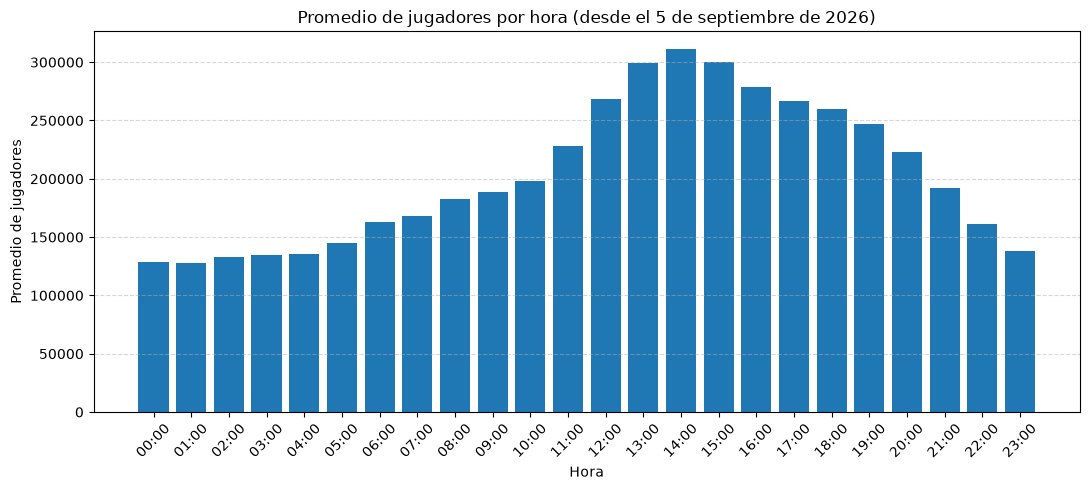

In [11]:
fecha_corte = pd.Timestamp("2026-09-05")
hora_reciente = promedio_hora(df, inicio=fecha_corte)

hora_maxima, hora_minima = max_min(hora_reciente)

print(
    f"Mayor promedio: a las {hora_maxima:02d}:00 "
    f"({hora_reciente.loc[hora_maxima]:,.0f} jugadores)"
)
print(
    f"Menor promedio: a las {hora_minima:02d}:00 "
    f"({hora_reciente.loc[hora_minima]:,.0f} jugadores)"
)

barras(
    [f"{hora:02d}:00" for hora in hora_reciente.index],
    hora_reciente.values,
    titulo="Promedio de jugadores por hora (desde el 5 de septiembre de 2026)",
    xlabel="Hora",
    ylabel="Promedio de jugadores",
)

### ¿Que juego ha tenido el pico mas grande de jugadores?

El máximo más alto fue de PUBG: 3,257,248 jugadores.


,Game,Máximo de jugadores
0,PUBG,3257248.0
1,Counter-Strike 2,1862531.0
2,Dota 2,1291328.0
3,Terraria,489886.0
4,Among Us,447476.0
5,Rust,262284.0
6,Team Fortress 2,253997.0
7,Stardew Valley,236614.0
8,Project Zomboid,124995.0
9,Hollow Knight,95655.0


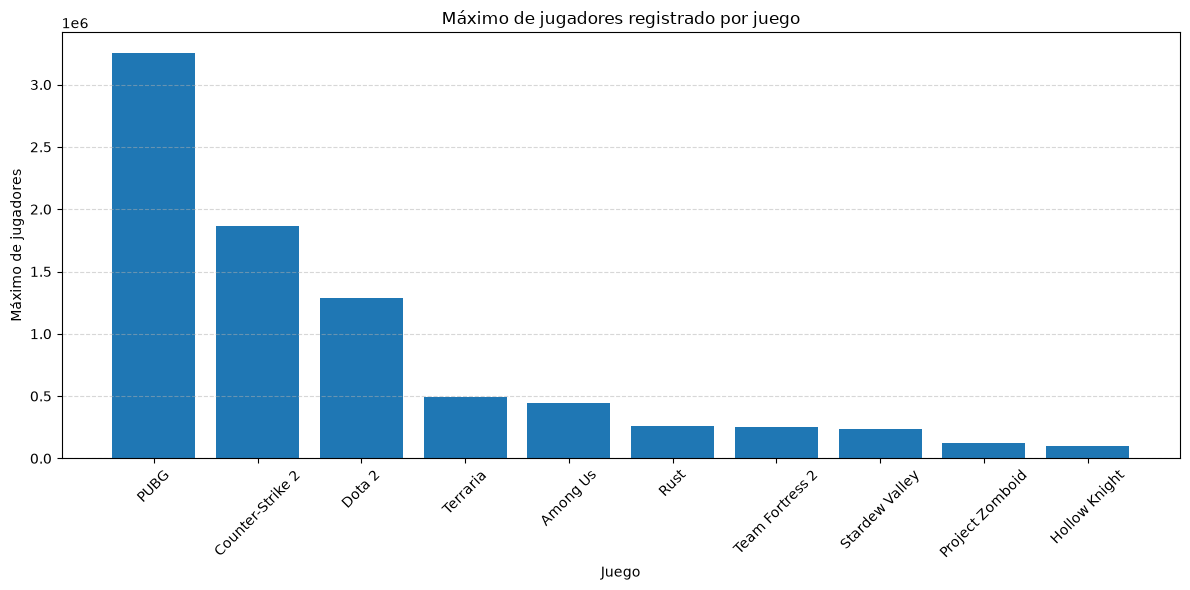

In [12]:
pico_maximos = (
    df.groupby("Game")["Players"]
    .max()
    .dropna()
    .sort_values(ascending=False)
)

print(f"El máximo más alto fue de {pico_maximos.index[0]}: "
      f"{pico_maximos.iloc[0]:,.0f} jugadores.")

tabla(
    pico_maximos.rename("Máximo de jugadores").to_frame().reset_index(),
    None,
)

barras(
    pico_maximos.index,
    pico_maximos.values,
    titulo="Máximo de jugadores registrado por juego",
    xlabel="Juego",
    ylabel="Máximo de jugadores",
    figsize=(12, 6),
)

### ¿Que juego ha retenido mejor a sus jugadores?

In [13]:
retencion_comparacion, retencion_historiales = calcular_retencion(diario_juego)

if retencion_comparacion.empty:
    print("No hay datos suficientes para comparar los juegos.")
else:
    retencion_mejor = retencion_comparacion.iloc[0]

    print(
        f"{retencion_mejor['Juego']} es el que mejor conserva su base: "
        f"mantiene el {retencion_mejor['% conservado del pico']:.2f} % "
        f"de su máximo diario."
    )

    tabla(retencion_comparacion, {
        "Pico de jugadores": "{:,.0f}",
        "Promedio actual de jugadores": "{:,.0f}",
        "% conservado del pico": formato_porcentaje,
        "% perdido": formato_porcentaje,
        "Fecha del pico": lambda fecha: fecha.strftime("%d/%m/%Y"),
        "Última fecha": lambda fecha: fecha.strftime("%d/%m/%Y"),
    })

Project Zomboid es el que mejor conserva su base: mantiene el 39.02 % de su máximo diario.


,Juego,Fecha del pico,Pico de jugadores,Última fecha,Promedio actual de jugadores,% conservado del pico,% perdido
0,Project Zomboid,09/08/2026,"124,995",05/10/2026,"48,773",39.02 %,60.98 %
1,Dota 2,06/03/2016,"1,291,328",05/10/2026,"437,260",33.86 %,66.14 %
2,Counter-Strike 2,12/04/2025,"1,862,531",05/10/2026,"512,665",27.53 %,72.47 %
3,Rust,02/01/2025,"262,284",05/10/2026,"64,043",24.42 %,75.58 %
4,Team Fortress 2,13/07/2023,"253,997",05/10/2026,"57,227",22.53 %,77.47 %
5,Stardew Valley,24/03/2024,"236,614",05/10/2026,"49,182",20.79 %,79.21 %
6,Terraria,16/05/2020,"489,886",05/10/2026,"28,692",5.86 %,94.14 %
7,PUBG,13/01/2018,"3,257,248",05/10/2026,"183,557",5.64 %,94.36 %
8,Hollow Knight,07/09/2025,"95,655",05/10/2026,"5,148",5.38 %,94.62 %
9,Among Us,26/09/2020,"447,476",05/10/2026,"7,475",1.67 %,98.33 %


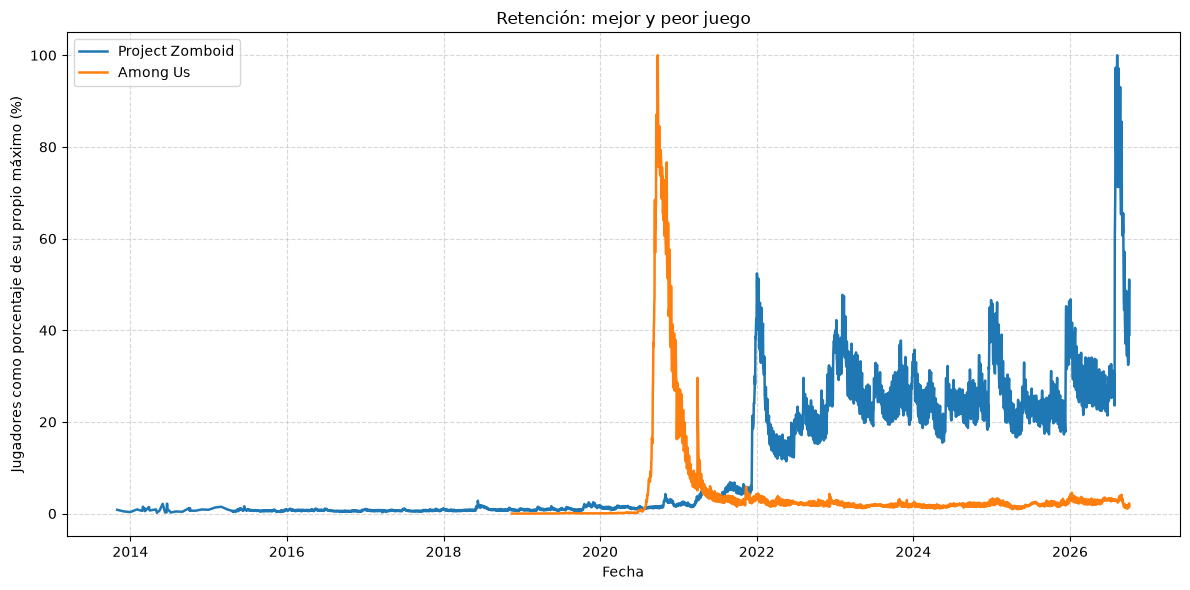

In [14]:
# Celda autosuficiente: recalcula en lugar de reutilizar variables ajenas.
plot_comparacion, plot_historiales = calcular_retencion(diario_juego)

retencion_mejor_juego = plot_comparacion.iloc[0]["Juego"]
retencion_peor_juego = plot_comparacion.iloc[-1]["Juego"]

plt.figure(figsize=(12, 6))

for juego in [retencion_mejor_juego, retencion_peor_juego]:
    historial, pico = plot_historiales[juego]
    porcentaje_del_pico = (historial["Players"] / pico * 100).round(2)

    plt.plot(
        historial["Fecha"],
        porcentaje_del_pico,
        label=juego,
        linewidth=1.8,
    )

ax = plt.gca()
configurar(ax, "Retención: mejor y peor juego", "Fecha",
           "Jugadores como porcentaje de su propio máximo (%)")
ax.legend()
plt.tight_layout()
plt.show()

### ¿Cual es el juego mas estable?

El juego más estable es Dota 2, con una variación relativa del 35.71 %.


,Game,Promedio diario,Desviación estándar,Variación relativa (%)
0,Dota 2,"644,359.31","230,129.29",35.71 %
1,Team Fortress 2,"66,126.45","26,156.19",39.55 %
2,Rust,"79,591.28","48,520.33",60.96 %
3,Counter-Strike 2,"755,362.79","470,759.31",62.32 %
4,PUBG,"706,335.26","534,671.37",75.70 %
5,Terraria,"30,641.73","23,866.02",77.89 %
6,Stardew Valley,"43,713.68","38,741.98",88.63 %
7,Hollow Knight,"7,150.23","7,811.00",109.24 %
8,Project Zomboid,"14,551.08","17,507.45",120.32 %
9,Among Us,"19,586.41","51,577.24",263.33 %


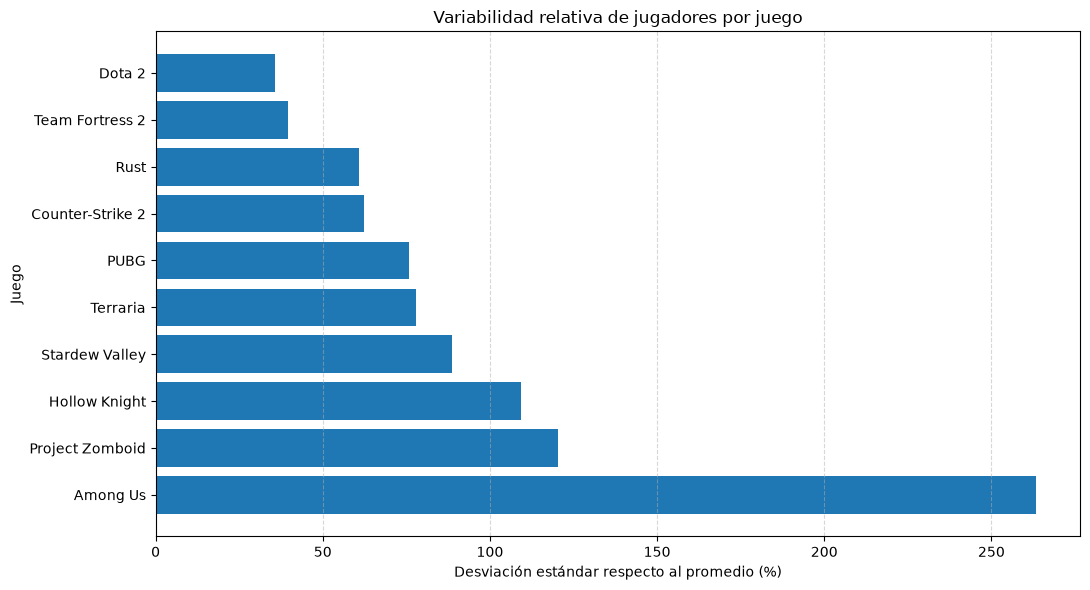

In [15]:
# Un promedio por juego y día (reutiliza el marco canonico diario).
estabilidad_base = diario_juego

# Variación de jugadores a lo largo de los días
estabilidad_tabla = (
    estabilidad_base.groupby("Game")["Players"]
    .agg(
        **{
            "Promedio diario": "mean",
            "Desviación estándar": "std"
        }
    )
    .reset_index()
)

# Porcentaje de variación respecto al promedio.
# Cuanto menor sea, más estable es el juego en relación con su tamaño.
estabilidad_tabla["Variación relativa (%)"] = (
    estabilidad_tabla["Desviación estándar"]
    / estabilidad_tabla["Promedio diario"]
    * 100
)

estabilidad_tabla = (
    estabilidad_tabla.dropna(subset=["Variación relativa (%)"])
    .sort_values("Variación relativa (%)")
    .reset_index(drop=True)
)

if estabilidad_tabla.empty:
    print("No hay datos suficientes para comparar la estabilidad.")
else:
    juego_mas_estable = estabilidad_tabla.iloc[0]

    print(
        f"El juego más estable es {juego_mas_estable['Game']}, "
        f"con una variación relativa del "
        f"{juego_mas_estable['Variación relativa (%)']:.2f} %."
    )

    tabla(estabilidad_tabla, {
        "Promedio diario": "{:,.2f}",
        "Desviación estándar": "{:,.2f}",
        "Variación relativa (%)": "{:.2f} %",
    })

    barras(
        estabilidad_tabla["Game"],
        estabilidad_tabla["Variación relativa (%)"],
        titulo="Variabilidad relativa de jugadores por juego",
        xlabel="Desviación estándar respecto al promedio (%)",
        ylabel="Juego",
        horizontal=True,
        figsize=(11, 6),
    )

### ¿Cual ha sido el año con mayor numero de jugadores?

El año con mayor promedio diario de jugadores fue 2025, con 3,286,738 jugadores.


,Año,Promedio diario de jugadores
0,2025,"3,286,738"
1,2026,"3,166,298"
2,2024,"3,072,523"
3,2018,"2,945,440"
4,2023,"2,685,585"
5,2017,"2,364,805"
6,2022,"2,350,769"
7,2020,"2,345,798"
8,2021,"2,242,377"
9,2019,"2,235,911"


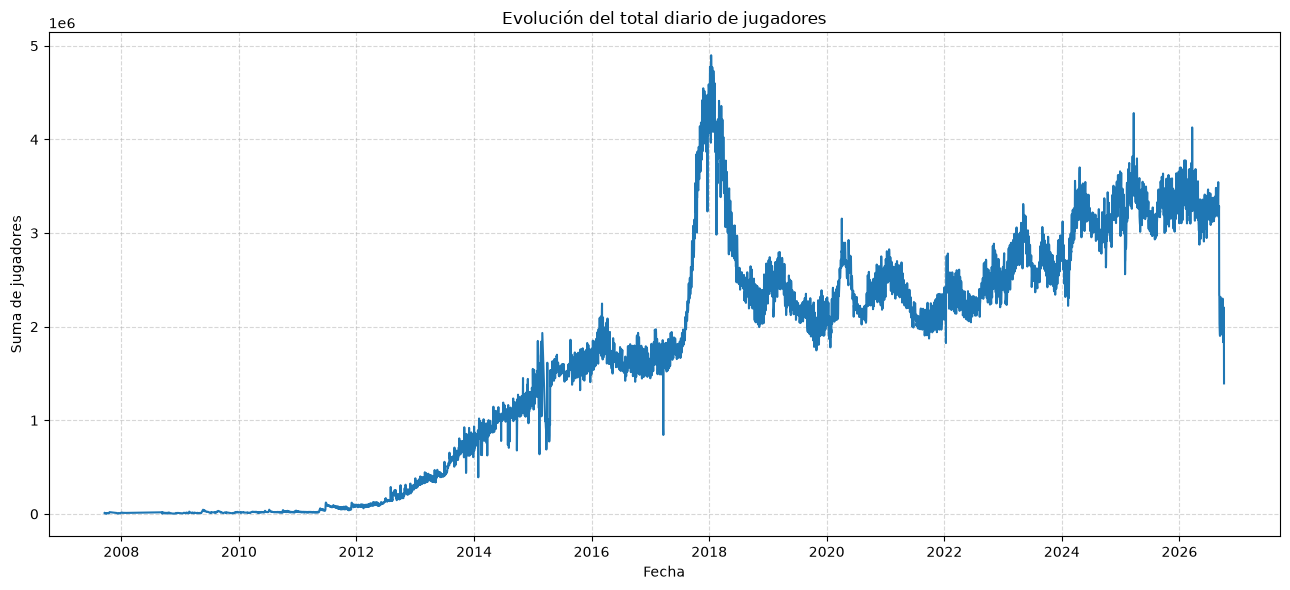

In [16]:
# Promedio diario por juego para que la frecuencia de medición no distorsione el resultado
anual_total = (
    diario_juego.groupby("Fecha")["Players"]
    .sum()
    .reset_index(name="Total de jugadores")
)
anual_total["Año"] = anual_total["Fecha"].dt.year

# Promedio del total diario para cada año
anual_jugadores = (
    anual_total.groupby("Año")["Total de jugadores"]
    .mean()
    .sort_values(ascending=False)
    .rename("Promedio diario de jugadores")
    .reset_index()
)

if anual_jugadores.empty:
    print("No hay datos suficientes para analizar los años.")
else:
    mejor_anio = anual_jugadores.iloc[0]

    print(
        f"El año con mayor promedio diario de jugadores fue "
        f"{int(mejor_anio['Año'])}, con "
        f"{mejor_anio['Promedio diario de jugadores']:,.0f} jugadores."
    )

    tabla(anual_jugadores, {"Promedio diario de jugadores": "{:,.0f}"})

    plt.figure(figsize=(13, 6))
    plt.plot(
        anual_total["Fecha"],
        anual_total["Total de jugadores"],
        linewidth=1.5,
    )
    ax = plt.gca()
    configurar(ax, "Evolución del total diario de jugadores",
               "Fecha", "Suma de jugadores")
    plt.tight_layout()
    plt.show()

- Hay que tener en cuenta que el año 2026 todavia no ha finalizado por lo que esos datos estan incompletos
- El pico al comienzo de 2018 se debe al pico de PUBG

### ¿Son los juegos mas populares actualmente mas antiguos o nuevos?

Popularidad calculada del 06/09/2026 al 05/10/2026.
Los tres juegos más populares son: Counter-Strike 2, Dota 2, PUBG.
Tienen una media de 13.19 años de historial, frente a 12.68 años del resto.
Los más populares tienen, en promedio, un historial más antiguo.


,Game,Promedio actual de jugadores,Días con datos recientes,Primer registro,Años de historial
0,Counter-Strike 2,831944,30,30/11/2011,14.85
1,Dota 2,587620,30,22/09/2011,15.04
2,PUBG,326319,30,01/02/2017,9.67
3,Rust,85976,30,01/12/2013,12.84
4,Team Fortress 2,59741,30,19/09/2007,19.04
5,Project Zomboid,53565,30,01/11/2013,12.93
6,Stardew Valley,50664,30,01/12/2015,10.84
7,Terraria,36254,30,15/05/2011,15.39
8,Among Us,7061,30,16/11/2018,7.89
9,Hollow Knight,6692,30,01/12/2016,9.84


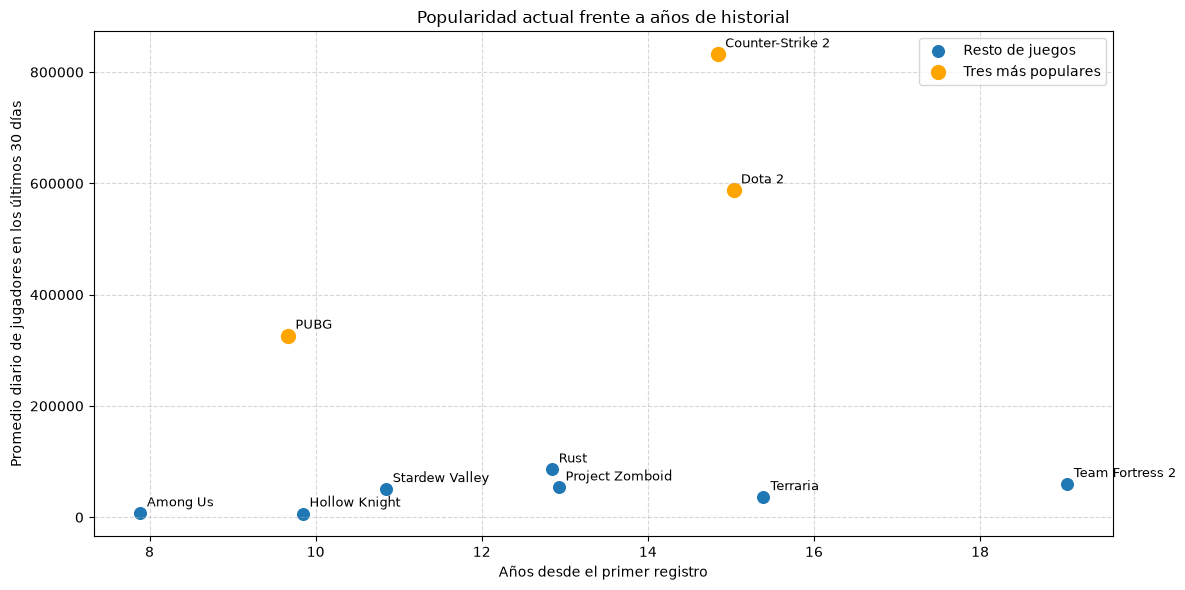

In [17]:
pop_fecha_final = diario_juego["Fecha"].max()
pop_fecha_inicio = pop_fecha_final - pd.Timedelta(days=29)

pop_primer_registro = df.groupby("Game")["Fecha"].min()

pop_recientes = diario_juego[
    diario_juego["Fecha"].between(pop_fecha_inicio, pop_fecha_final)
]

pop_comparacion = (
    pop_recientes.groupby("Game")["Players"]
    .agg(
        **{
            "Promedio actual de jugadores": "mean",
            "Días con datos recientes": "count"
        }
    )
    .join(pop_primer_registro.rename("Primer registro"))
    .reset_index()
)

pop_comparacion["Años de historial"] = (
    (pop_fecha_final - pop_comparacion["Primer registro"]).dt.days / 365.25
)

pop_comparacion = (
    pop_comparacion.dropna(subset=["Promedio actual de jugadores"])
    .sort_values("Promedio actual de jugadores", ascending=False)
    .reset_index(drop=True)
)

if len(pop_comparacion) < 4:
    print("Se necesitan al menos cuatro juegos para comparar los tres más populares con el resto.")
else:
    top_tres = pop_comparacion.head(3)
    resto = pop_comparacion.iloc[3:]

    historial_top = top_tres["Años de historial"].mean()
    historial_resto = resto["Años de historial"].mean()

    print(
        f"Popularidad calculada del {pop_fecha_inicio:%d/%m/%Y} "
        f"al {pop_fecha_final:%d/%m/%Y}."
    )
    print(
        f"Los tres juegos más populares son: "
        f"{', '.join(top_tres['Game'])}."
    )
    print(
        f"Tienen una media de {historial_top:.2f} años de historial, "
        f"frente a {historial_resto:.2f} años del resto."
    )

    if historial_top > historial_resto:
        print("Los más populares tienen, en promedio, un historial más antiguo.")
    elif historial_top < historial_resto:
        print("Los más populares tienen, en promedio, un historial más reciente.")
    else:
        print("Ambos grupos tienen la misma antigüedad media del historial.")

    tabla(pop_comparacion, {
        "Promedio actual de jugadores": "{:.0f}",
        "Primer registro": lambda fecha: fecha.strftime("%d/%m/%Y"),
        "Años de historial": "{:.2f}",
    })

    plt.figure(figsize=(12, 6))
    plt.scatter(
        resto["Años de historial"],
        resto["Promedio actual de jugadores"],
        label="Resto de juegos",
        s=70,
    )
    plt.scatter(
        top_tres["Años de historial"],
        top_tres["Promedio actual de jugadores"],
        color="orange",
        label="Tres más populares",
        s=100,
    )

    for _, fila in pop_comparacion.iterrows():
        plt.annotate(
            fila["Game"],
            (fila["Años de historial"], fila["Promedio actual de jugadores"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    ax = plt.gca()
    configurar(ax, "Popularidad actual frente a años de historial",
               "Años desde el primer registro",
               "Promedio diario de jugadores en los últimos 30 días")
    ax.legend()
    plt.tight_layout()
    plt.show()

### ¿Que juegos han crecido en jugadores en el ultimo año?

Período actual: 06/09/2026 – 05/10/2026
Período anterior: 06/09/2025 – 05/10/2025
Han crecido: Project Zomboid, Terraria, Team Fortress 2.


,Game,Promedio actual,Días actuales con datos,Promedio hace un año,Días anteriores con datos,Cambio de jugadores,Cambio (%)
0,Project Zomboid,53565,30,26765,30,+26801,+100.13 %
1,Terraria,36254,30,29652,30,+6602,+22.26 %
2,Team Fortress 2,59741,30,57460,30,+2281,+3.97 %
3,Among Us,7061,30,9598,30,-2537,-26.44 %
4,Dota 2,587620,30,831639,30,-244018,-29.34 %
5,Rust,85976,30,126455,30,-40479,-32.01 %
6,Counter-Strike 2,831944,30,1432659,30,-600715,-41.93 %
7,PUBG,326319,30,652678,30,-326359,-50.00 %
8,Stardew Valley,50664,30,102624,30,-51960,-50.63 %
9,Hollow Knight,6692,30,65325,30,-58633,-89.76 %


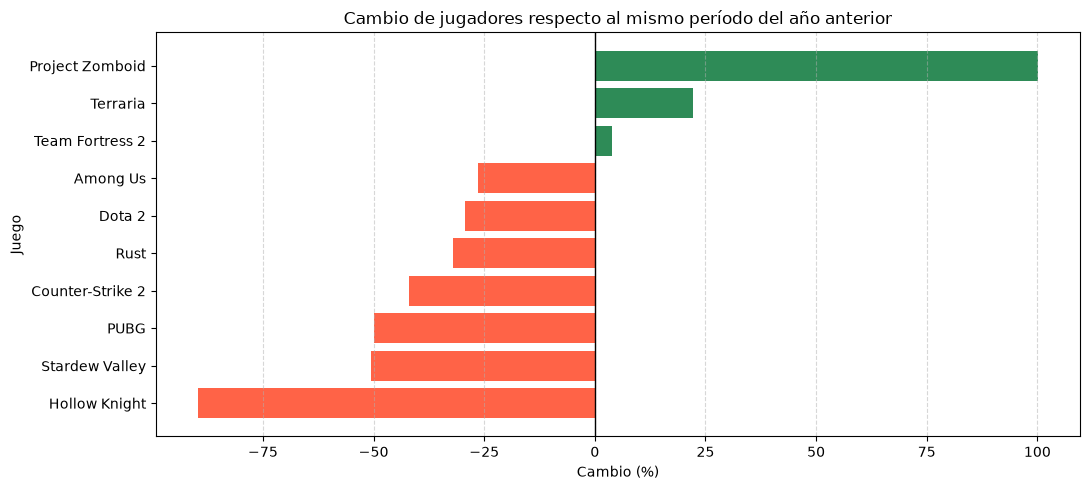

In [18]:
crec_fecha_final = diario_juego["Fecha"].max()
crec_inicio_actual = crec_fecha_final - pd.Timedelta(days=29)

crec_fin_anterior = crec_fecha_final - pd.DateOffset(years=1)
crec_inicio_anterior = crec_fin_anterior - pd.Timedelta(days=29)

crec_actual = diario_juego[
    diario_juego["Fecha"].between(crec_inicio_actual, crec_fecha_final)
]
crec_anterior = diario_juego[
    diario_juego["Fecha"].between(crec_inicio_anterior, crec_fin_anterior)
]

crec_resumen_actual = crec_actual.groupby("Game")["Players"].agg(
    **{
        "Promedio actual": "mean",
        "Días actuales con datos": "count"
    }
)

crec_resumen_anterior = crec_anterior.groupby("Game")["Players"].agg(
    **{
        "Promedio hace un año": "mean",
        "Días anteriores con datos": "count"
    }
)

crec_comparacion = (
    crec_resumen_actual.join(crec_resumen_anterior, how="outer")
    .reset_index()
)

# Solo compara períodos completos y bases positivas.
crec_comparables = (
    crec_comparacion["Días actuales con datos"].eq(30)
    & crec_comparacion["Días anteriores con datos"].eq(30)
    & crec_comparacion["Promedio hace un año"].gt(0)
)

crec_no_comparables = crec_comparacion.loc[~crec_comparables, "Game"]
crec_comparacion = crec_comparacion.loc[crec_comparables].copy()

crec_comparacion["Cambio de jugadores"] = (
    crec_comparacion["Promedio actual"]
    - crec_comparacion["Promedio hace un año"]
)
crec_comparacion["Cambio (%)"] = (
    crec_comparacion["Cambio de jugadores"]
    / crec_comparacion["Promedio hace un año"]
    * 100
)

crec_comparacion = crec_comparacion.sort_values(
    "Cambio (%)", ascending=False
).reset_index(drop=True)

print(
    f"Período actual: {crec_inicio_actual:%d/%m/%Y} "
    f"– {crec_fecha_final:%d/%m/%Y}"
)
print(
    f"Período anterior: {crec_inicio_anterior:%d/%m/%Y} "
    f"– {crec_fin_anterior:%d/%m/%Y}"
)

if not crec_no_comparables.empty:
    print(
        "No se pueden comparar por datos incompletos o promedio anterior "
        f"no positivo: {', '.join(crec_no_comparables)}."
    )

if crec_comparacion.empty:
    print("No hay juegos con datos suficientes para esta comparación.")
else:
    juegos_crecidos = crec_comparacion.loc[
        crec_comparacion["Cambio (%)"] > 0, "Game"
    ]

    if juegos_crecidos.empty:
        print("Ningún juego ha crecido en los períodos comparados.")
    else:
        print(f"Han crecido: {', '.join(juegos_crecidos)}.")

    tabla(crec_comparacion, {
        "Promedio actual": "{:.0f}",
        "Promedio hace un año": "{:.0f}",
        "Cambio de jugadores": "{:+.0f}",
        "Cambio (%)": "{:+.2f} %",
    })

    colores = [
        "seagreen" if cambio > 0 else "tomato"
        for cambio in crec_comparacion["Cambio (%)"]
    ]

    barras(
        crec_comparacion["Game"],
        crec_comparacion["Cambio (%)"],
        titulo="Cambio de jugadores respecto al mismo período del año anterior",
        xlabel="Cambio (%)",
        ylabel="Juego",
        horizontal=True,
        color=colores,
        linea_cero=True,
    )

### ¿Hay algun pico o tendencia que se repita a lo largo de varios juegos?

,Mes,Juegos que crecieron,Juegos comparables,Juegos
0,2020-04,10,10,"Among Us, Counter-Strike 2, Dota 2, Hollow Kni..."
1,2019-01,9,10,"Among Us, Counter-Strike 2, Dota 2, Hollow Kni..."
2,2024-12,9,10,"Among Us, Counter-Strike 2, Hollow Knight, PUB..."
3,2025-12,9,10,"Among Us, Counter-Strike 2, Dota 2, PUBG, Proj..."
4,2017-12,8,9,"Counter-Strike 2, Dota 2, Hollow Knight, PUBG,..."
5,2018-01,8,9,"Counter-Strike 2, Hollow Knight, PUBG, Project..."
6,2020-03,8,10,"Among Us, Counter-Strike 2, Dota 2, Project Zo..."
7,2020-11,8,10,"Counter-Strike 2, Dota 2, Hollow Knight, PUBG,..."
8,2021-01,8,10,"Counter-Strike 2, Dota 2, Hollow Knight, PUBG,..."
9,2021-11,8,10,"Among Us, Counter-Strike 2, Hollow Knight, Pro..."


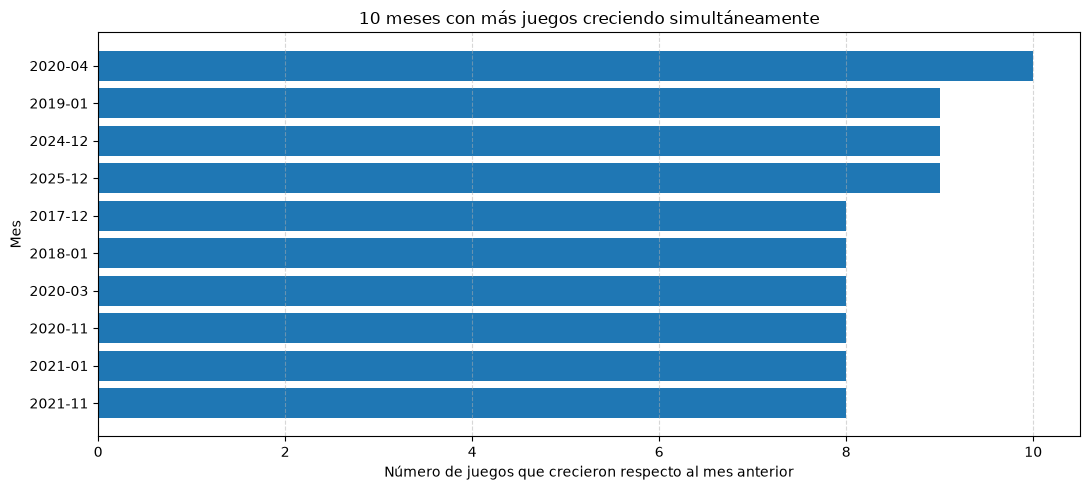

In [19]:
patron_mensuales = (
    diario_juego.assign(Mes=diario_juego["Fecha"].dt.to_period("M"))
    .groupby(["Game", "Mes"])["Players"]
    .agg(Promedio="mean", Dias_con_datos="count")
    .reset_index()
)

# Evita comparar meses con una cobertura muy incompleta.
patron_mensuales["Dias_del_mes"] = patron_mensuales["Mes"].dt.days_in_month
patron_mensuales.loc[
    patron_mensuales["Dias_con_datos"] / patron_mensuales["Dias_del_mes"] < 0.8,
    "Promedio"
] = float("nan")

patron_pivote = patron_mensuales.pivot(
    index="Mes", columns="Game", values="Promedio"
).sort_index()

patron_calendario = pd.period_range(
    patron_pivote.index.min(), patron_pivote.index.max(), freq="M"
)
patron_pivote = patron_pivote.reindex(patron_calendario)

patron_comparables = patron_pivote.notna() & patron_pivote.shift(1).notna()
patron_crecen = patron_pivote.gt(patron_pivote.shift(1)) & patron_comparables

patron_resumen = pd.DataFrame({
    "Juegos que crecieron": patron_crecen.sum(axis=1),
    "Juegos comparables": patron_comparables.sum(axis=1),
})

patron_resumen = patron_resumen[patron_resumen["Juegos que crecieron"] > 0].copy()
patron_resumen["Juegos"] = [
    ", ".join(patron_crecen.columns[patron_crecen.loc[mes]])
    for mes in patron_resumen.index
]

# En caso de empate, aparece primero el mes más antiguo.
patron_top10 = (
    patron_resumen.sort_values("Juegos que crecieron", ascending=False, kind="stable")
    .head(10)
    .reset_index(names="Mes")
)
patron_top10["Mes"] = patron_top10["Mes"].astype(str)

display(patron_top10)

barras(
    patron_top10["Mes"],
    patron_top10["Juegos que crecieron"],
    titulo="10 meses con más juegos creciendo simultáneamente",
    xlabel="Número de juegos que crecieron respecto al mes anterior",
    ylabel="Mes",
    horizontal=True,
)

### ¿Cual es la tendencia general respecto a la popularidad de los videojuegos?

En 2023–2025, el juego típico varió un +5.37 % anual: la tendencia reciente es creciente.


,Año,Juegos comparados,Juegos que crecieron,Crecimiento mediano (%),% de juegos que crecieron
0,2011,1,1,+86.00 %,100.00 %
1,2012,1,1,+50.36 %,100.00 %
2,2013,3,3,+78.32 %,100.00 %
3,2014,4,3,+51.16 %,75.00 %
4,2015,5,4,+17.38 %,80.00 %
5,2016,5,3,+6.12 %,60.00 %
6,2017,7,3,-0.76 %,42.86 %
7,2018,8,4,+4.35 %,50.00 %
8,2019,9,7,+19.70 %,77.78 %
9,2020,10,8,+47.05 %,80.00 %


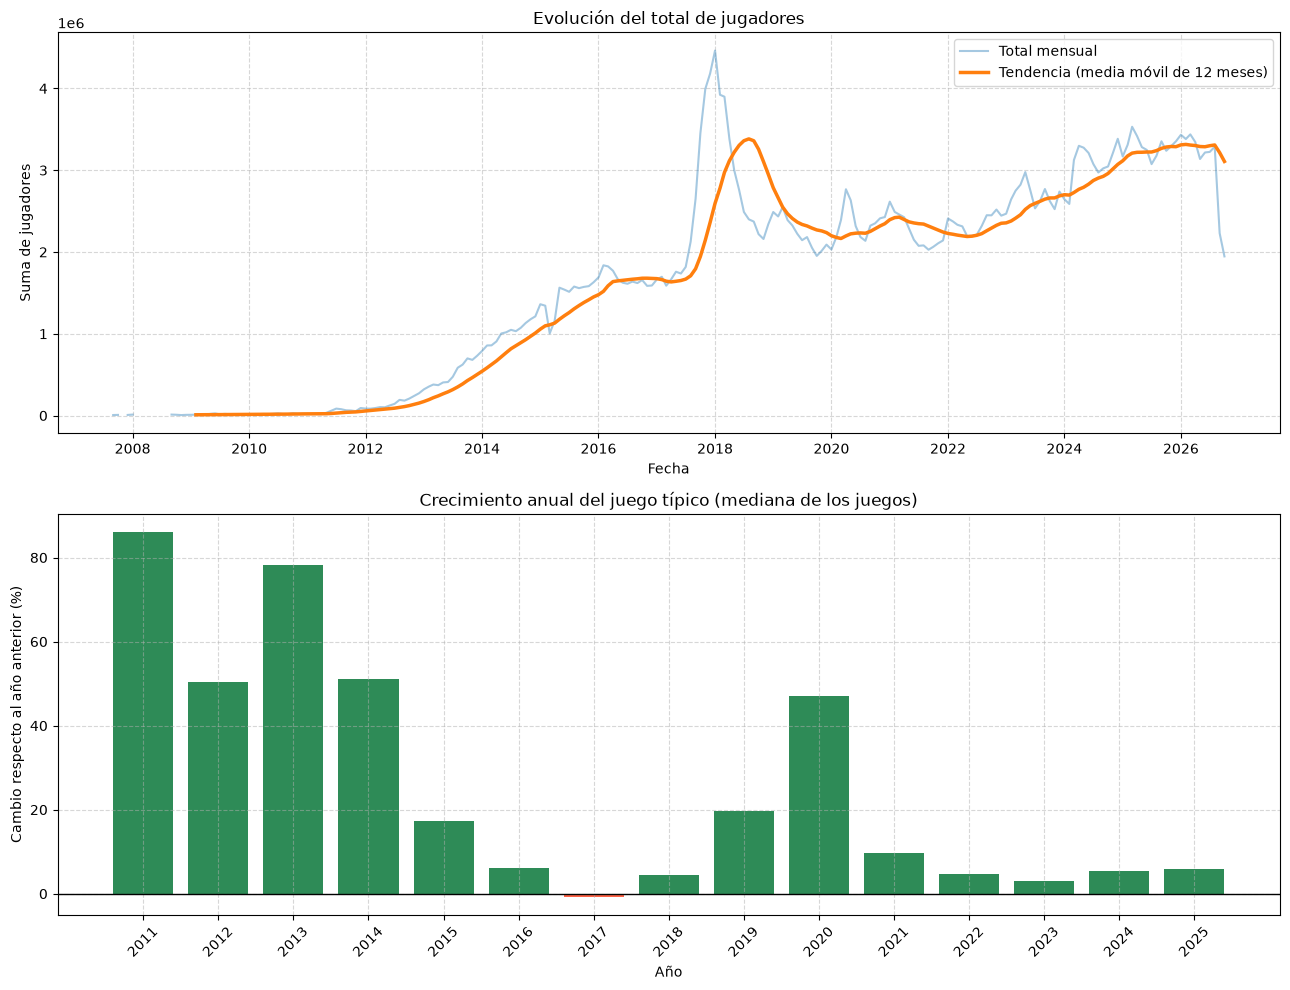

In [20]:
# 1. Evolución del total de jugadores
tend_total_mensual = (
    diario_juego.groupby("Fecha")["Players"].sum()
    .resample("MS")
    .mean()
)
tend_media_12 = tend_total_mensual.rolling(12, min_periods=6).mean()

# 2. Crecimiento anual de cada juego respecto a sí mismo
tend_diarios = diario_juego.assign(Año=diario_juego["Fecha"].dt.year)
tend_anuales = (
    tend_diarios.groupby(["Game", "Año"])["Players"]
    .agg(Promedio="mean", Dias_con_datos="count")
    .reset_index()
)

# Solo se usan años con al menos 300 días de datos para comparar años completos.
tend_anuales = tend_anuales[tend_anuales["Dias_con_datos"] >= 300]

tend_pivote = tend_anuales.pivot(index="Año", columns="Game", values="Promedio")
tend_pivote = tend_pivote.reindex(
    range(tend_pivote.index.min(), tend_pivote.index.max() + 1)
)
tend_anterior = tend_pivote.shift(1)
tend_cambios = ((tend_pivote / tend_anterior - 1) * 100).where(tend_anterior > 0)

tend_resumen = pd.DataFrame({
    "Juegos comparados": tend_cambios.count(axis=1),
    "Juegos que crecieron": (tend_cambios > 0).sum(axis=1),
    "Crecimiento mediano (%)": tend_cambios.median(axis=1),
})
tend_resumen = tend_resumen[tend_resumen["Juegos comparados"] > 0]
tend_resumen["% de juegos que crecieron"] = (
    tend_resumen["Juegos que crecieron"]
    / tend_resumen["Juegos comparados"]
    * 100
)
tend_resumen = tend_resumen.reset_index(names="Año")

# Conclusión basada en los últimos 3 años comparables
tend_ultimos = tend_resumen.tail(3)

if tend_ultimos.empty:
    print("No hay suficientes años completos para comparar.")
else:
    tend_mediana = tend_ultimos["Crecimiento mediano (%)"].median()
    tend_anios = f"{tend_ultimos['Año'].min()}–{tend_ultimos['Año'].max()}"

    if tend_mediana > 0:
        tendencia = "creciente"
    elif tend_mediana < 0:
        tendencia = "decreciente"
    else:
        tendencia = "estable"

    print(
        f"En {tend_anios}, el juego típico varió un {tend_mediana:+.2f} % "
        f"anual: la tendencia reciente es {tendencia}."
    )

tabla(tend_resumen, {
    "Crecimiento mediano (%)": "{:+.2f} %",
    "% de juegos que crecieron": "{:.2f} %",
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10))

ax1.plot(tend_total_mensual.index, tend_total_mensual.values, alpha=0.4, label="Total mensual")
ax1.plot(
    tend_media_12.index,
    tend_media_12.values,
    linewidth=2.5,
    label="Tendencia (media móvil de 12 meses)",
)
configurar(ax1, "Evolución del total de jugadores", "Fecha", "Suma de jugadores")
ax1.legend()

tend_colores = [
    "seagreen" if valor > 0 else "tomato"
    for valor in tend_resumen["Crecimiento mediano (%)"]
]
ax2.bar(
    tend_resumen["Año"].astype(str),
    tend_resumen["Crecimiento mediano (%)"],
    color=tend_colores,
)
ax2.axhline(0, color="black", linewidth=1)
configurar(ax2, "Crecimiento anual del juego típico (mediana de los juegos)",
           "Año", "Cambio respecto al año anterior (%)", rotacion_x=45)

plt.tight_layout()
plt.show()